In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [11]:
# Load the dataset

df = pd.read_csv("D:\College Internships\Data Science SY(sem-2)2026\Customer-Churn-Prediction\Data\Telco-Customer-Churn.csv")

# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [13]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df.isna().sum().sum()

np.int64(0)

In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [18]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [20]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [21]:
df["TotalCharges"].dtype

dtype('O')

In [22]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [23]:
# Convert TotalCharges from object to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values created during conversion
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Missing TotalCharges: 11


In [24]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df = df.drop("customerID", axis=1, errors="ignore")

In [27]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [29]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [30]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


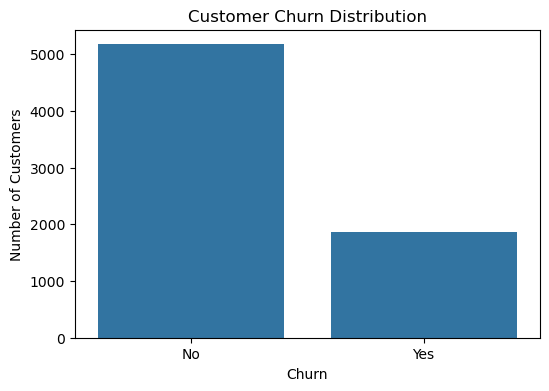

In [31]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [32]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


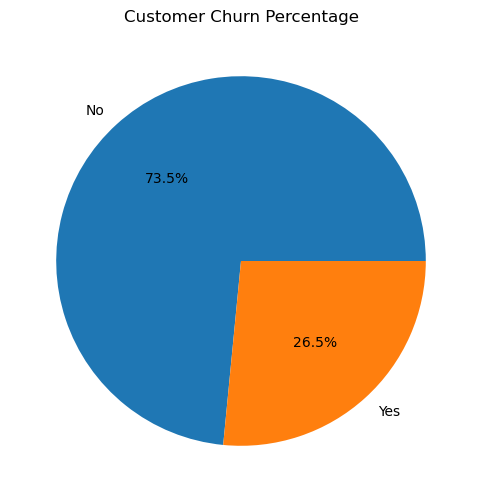

In [33]:
plt.figure(figsize=(6, 6))

plt.pie(
    churn_percentage,
    labels=churn_percentage.index,
    autopct="%1.1f%%"
)

plt.title("Customer Churn Percentage")

plt.show()

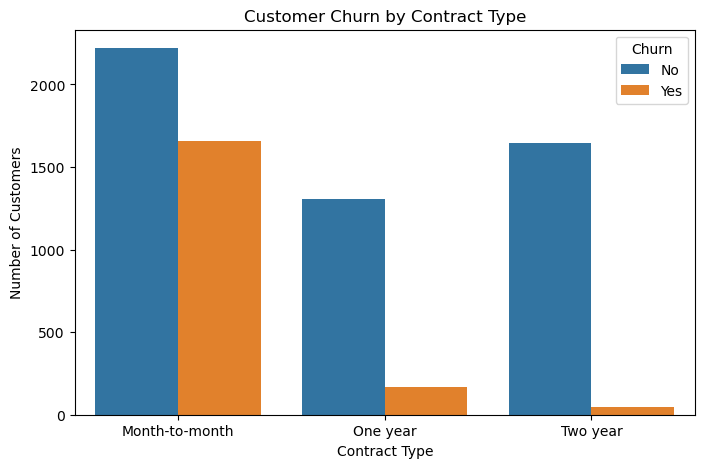

In [34]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [35]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


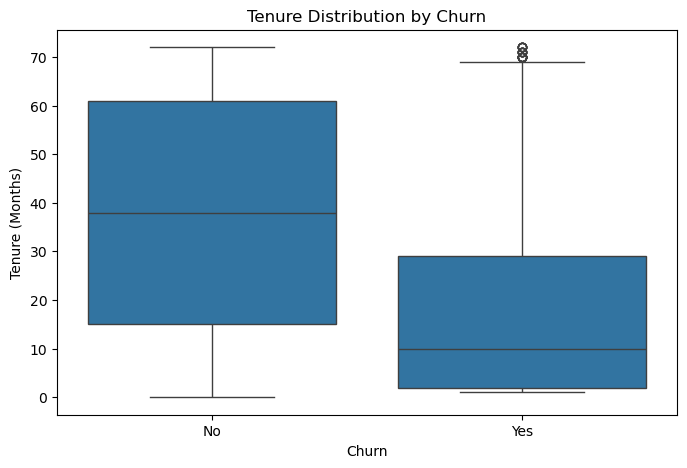

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

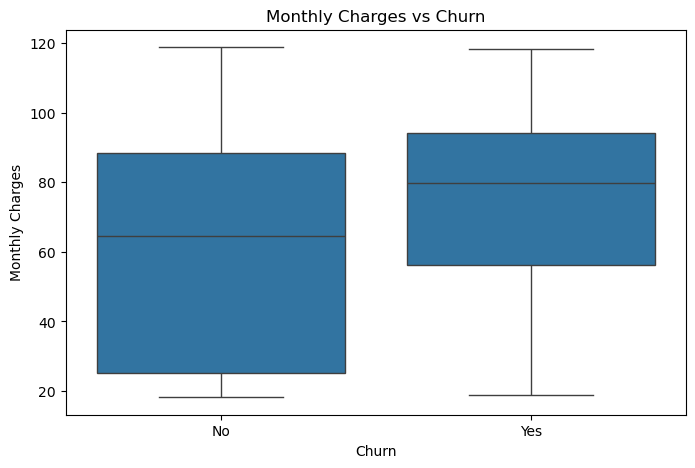

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

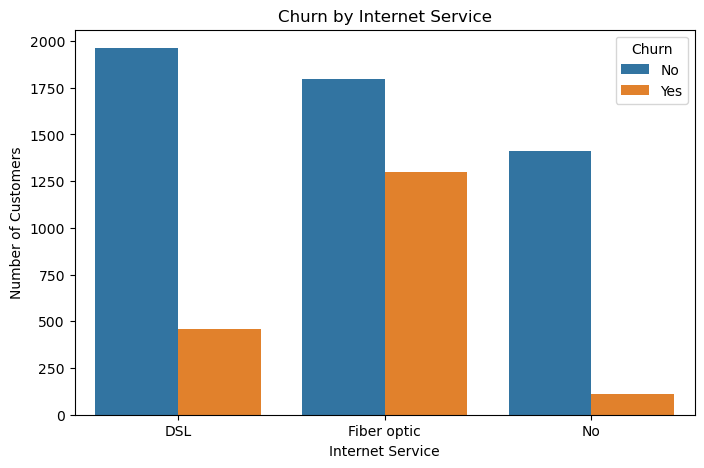

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

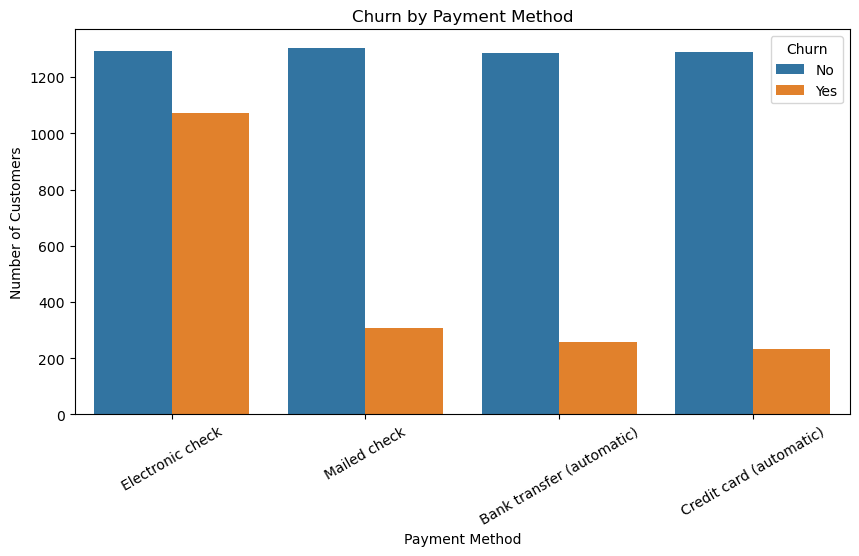

In [39]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

In [40]:
df["Churn_numeric"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [41]:
correlation = df.select_dtypes(
    include=["int64", "float64"]
).corr()

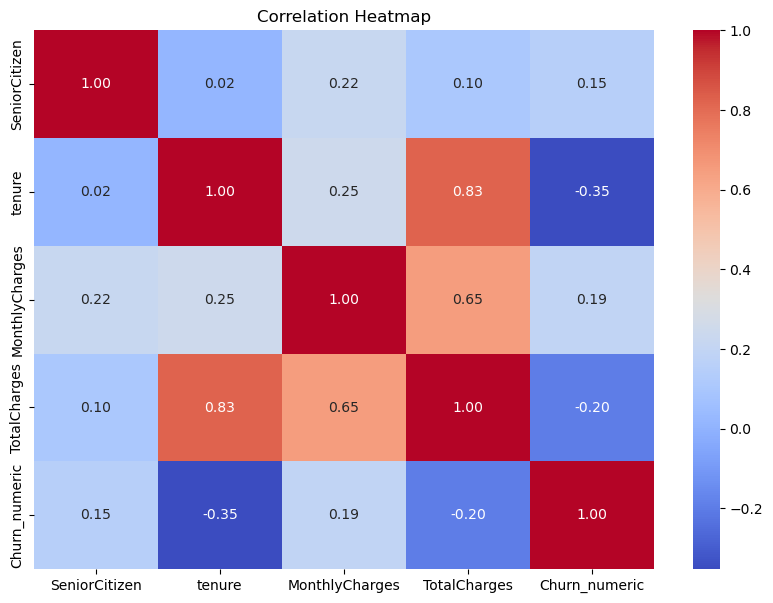

In [42]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [43]:
df.drop("Churn_numeric", axis=1, inplace=True)

In [44]:
print(df.shape)
df.head()

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [46]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [47]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [48]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 19)
Target: (7043,)


In [49]:
categorical_columns = X.select_dtypes(include="object").columns

print(categorical_columns.tolist())

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [50]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

In [51]:
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [52]:
print("Original features:", X.shape[1])
print("Encoded features:", X_encoded.shape[1])

Original features: 19
Encoded features: 30


In [53]:
X_encoded = X_encoded.astype(int)

In [54]:
X_encoded.dtypes.value_counts()

int64    30
Name: count, dtype: int64

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [57]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64


In [58]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [59]:
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [60]:
print("Original X:", X.shape)
print("Training X:", X_train.shape)
print("Testing X:", X_test.shape)
print("SMOTE Training X:", X_train_smote.shape)

print("\nOriginal target:")
print(y.value_counts())

print("\nSMOTE target:")
print(y_train_smote.value_counts())

Original X: (7043, 19)
Training X: (5634, 30)
Testing X: (1409, 30)
SMOTE Training X: (8278, 30)

Original target:
Churn
0    5174
1    1869
Name: count, dtype: int64

SMOTE target:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [61]:
print("Training data:", X_train_smote.shape)
print("Testing data:", X_test.shape)
print("Training labels:", y_train_smote.shape)
print("Testing labels:", y_test.shape)

Training data: (8278, 30)
Testing data: (1409, 30)
Training labels: (8278,)
Testing labels: (1409,)


In [62]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [63]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409

ROC-AUC: 0.8334237515823194


In [64]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

decision_tree.fit(
    X_train_smote,
    y_train_smote
)

y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [65]:
print("Decision Tree")
print(classification_report(y_test, y_pred_dt))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_dt))

Decision Tree
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1035
           1       0.54      0.64      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.77      1409

ROC-AUC: 0.8074582138520758


In [66]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10,
    n_jobs=-1
)

random_forest.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [67]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC: 0.8290268413030563


In [68]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [69]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [70]:
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_xgb))

XGBoost
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.56      0.65      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409

ROC-AUC: 0.8347309411248031


In [71]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results = results.sort_values(
    by="F1 Score",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.778566,0.570776,0.668449,0.615764,0.833424
2,Random Forest,0.761533,0.539256,0.697861,0.608392,0.829027
3,XGBoost,0.770759,0.558891,0.647059,0.599752,0.834731
1,Decision Tree,0.762243,0.544018,0.644385,0.589963,0.807458


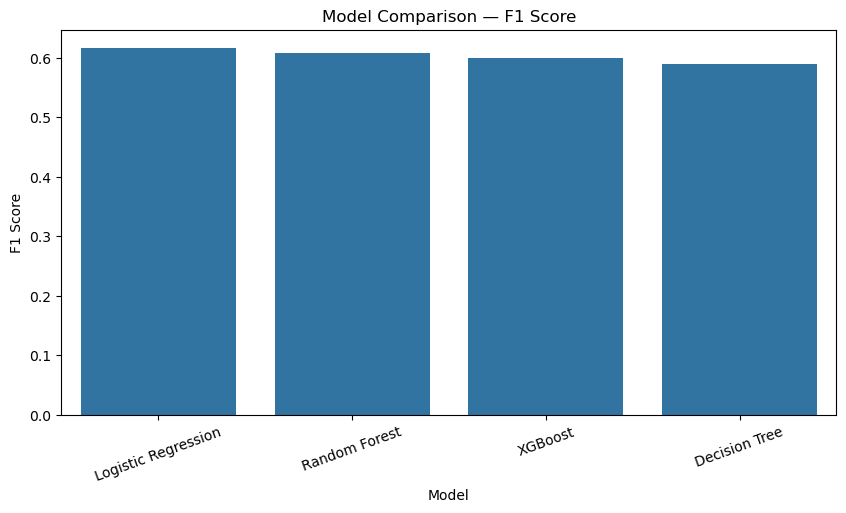

In [72]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparison — F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.show()

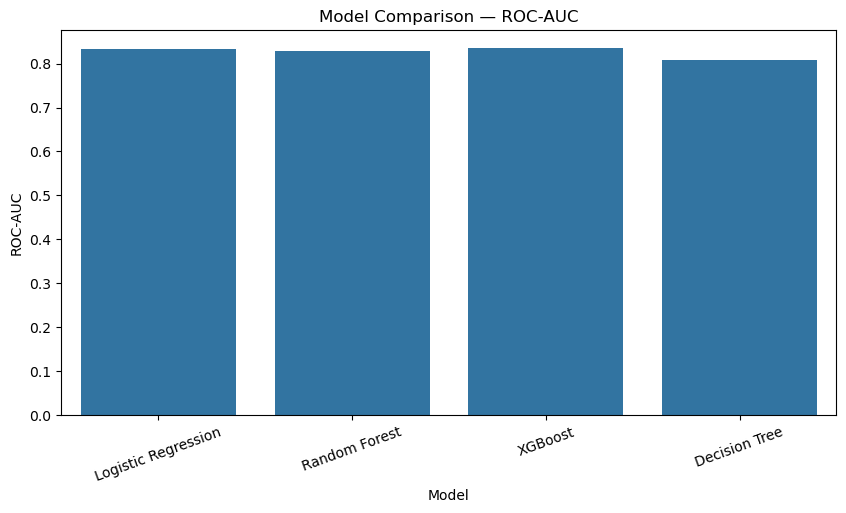

In [73]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="ROC-AUC"
)

plt.title("Model Comparison — ROC-AUC")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=20)

plt.show()

In [74]:
best_model_name = results.iloc[0]["Model"]

print("Best model:", best_model_name)

Best model: Logistic Regression


In [75]:
best_model = logistic_model

print("Final Model: Logistic Regression")
print()
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Final Model: Logistic Regression

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409

ROC-AUC: 0.8334237515823194


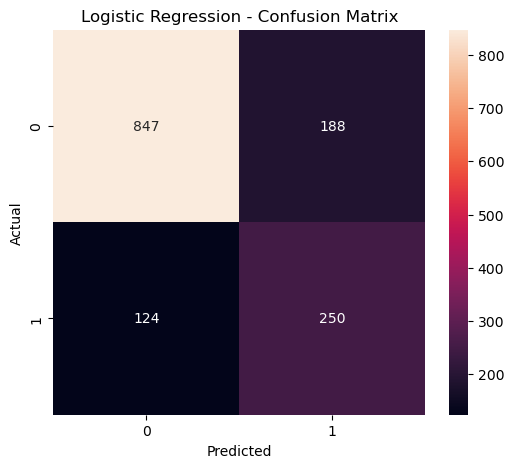

In [76]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

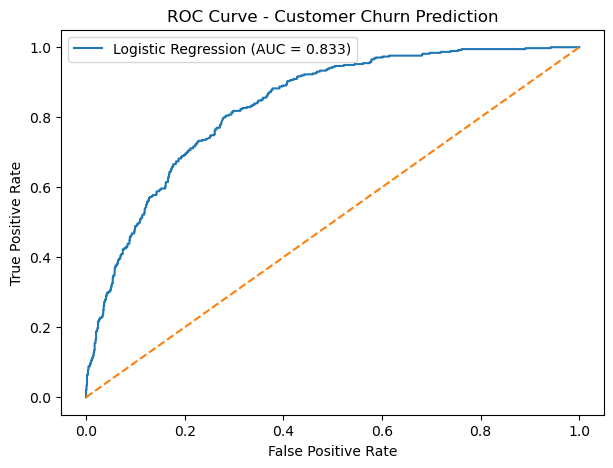

In [77]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")

plt.legend()
plt.show()

In [78]:
feature_importance = pd.DataFrame({
    "Feature": X_train_smote.columns,
    "Coefficient": logistic_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
7,PhoneService_Yes,-5.574030,5.574030
10,InternetService_Fiber optic,-3.736405,3.736405
25,Contract_Two year,-2.310737,2.310737
13,OnlineSecurity_Yes,-1.694172,1.694172
21,StreamingTV_Yes,-1.640276,1.640276
23,StreamingMovies_Yes,-1.613358,1.613358
19,TechSupport_Yes,-1.580058,1.580058
8,MultipleLines_No phone service,-1.468845,1.468845
15,OnlineBackup_Yes,-1.412278,1.412278
24,Contract_One year,-1.283431,1.283431


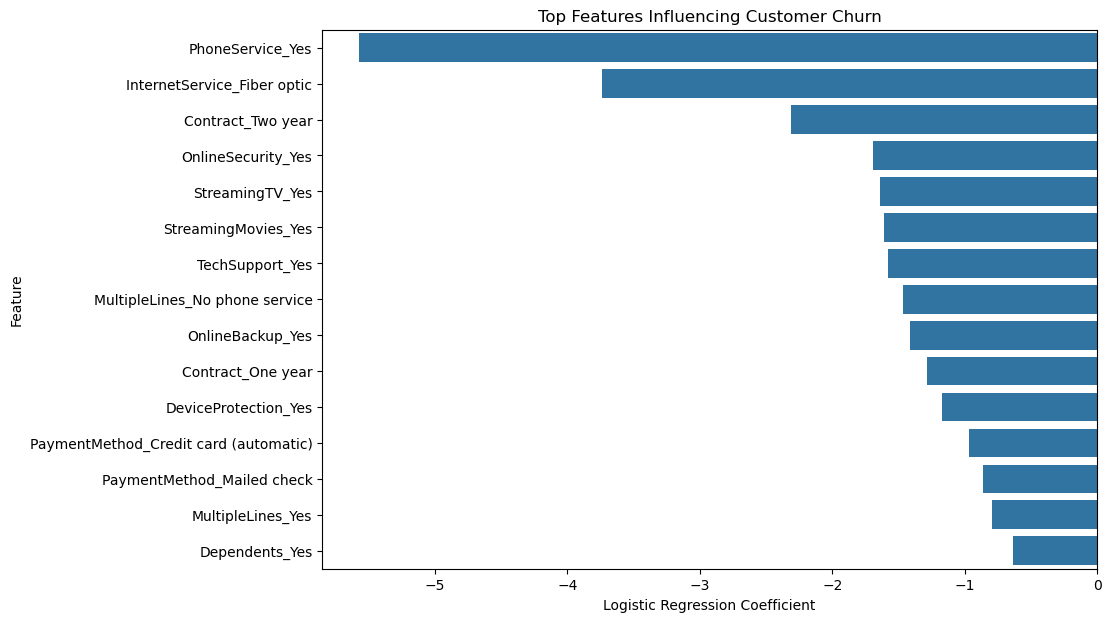

In [79]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [80]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [81]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder is ready.")

Models folder is ready.


In [82]:
import joblib

joblib.dump(
    logistic_model,
    "../models/customer_churn_logistic_regression.pkl"
)

joblib.dump(
    X_train_smote.columns.tolist(),
    "../models/model_features.pkl"
)

print("Model and feature list saved successfully!")

Model and feature list saved successfully!


In [83]:
import joblib

logistic_model = joblib.load(
    "../models/customer_churn_logistic_regression.pkl"
)

model_features = joblib.load(
    "../models/model_features.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [84]:
def predict_churn(customer_data):

    # Convert input dictionary into DataFrame
    input_df = pd.DataFrame([customer_data])

    # Apply same one-hot encoding used during training
    input_encoded = pd.get_dummies(input_df)

    # Make sure input has exactly the same features as training data
    input_encoded = input_encoded.reindex(
        columns=model_features,
        fill_value=0
    )

    # Convert data type
    input_encoded = input_encoded.astype(int)

    # Predict probability
    probability = logistic_model.predict_proba(
        input_encoded
    )[0][1]

    # Prediction
    prediction = logistic_model.predict(
        input_encoded
    )[0]

    # Risk level
    if probability >= 0.70:
        risk = "HIGH RISK"
    elif probability >= 0.40:
        risk = "MEDIUM RISK"
    else:
        risk = "LOW RISK"

    return probability, prediction, risk

In [85]:
sample_customer = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 80.0,
    "TotalCharges": 160.0
}

In [86]:
probability, prediction, risk = predict_churn(
    sample_customer
)

print("Customer Churn Prediction")
print("-------------------------")
print(f"Churn Probability: {probability:.2%}")
print(f"Prediction: {'CHURN' if prediction == 1 else 'NO CHURN'}")
print(f"Risk Level: {risk}")

Customer Churn Prediction
-------------------------
Churn Probability: 96.85%
Prediction: CHURN
Risk Level: HIGH RISK
